# Caracterización de la Guitarra

## Objetivo

Redescubrir desde los datos experimentales la ecuación:

$$\boxed{f = \frac{1}{2L}\sqrt{\frac{T}{\mu}}}$$

donde:
- $f$ = frecuencia fundamental [Hz]
- $L$ = longitud vibrante de la cuerda [m]
- $T$ = tensión en la cuerda [N]
- $\mu$ = densidad lineal (masa por unidad de longitud) [kg/m]

## Datos disponibles

| Experimento | Variables que cambian | Variables fijas |
|---|---|---|
| Trastes (0–6) por cuerda | $L$, $f$ | $T$, $\mu$ (por cuerda) |
| Clavijero (−900° a +180°) por cuerda | $T$, $f$ | $L$ = 65 cm, $\mu$ (por cuerda) |

Juntos cubren variación independiente en las tres variables de entrada.

## Intalación de librerias

In [82]:
%matplotlib inline

# Librerías científicas y de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Utilidades del sistema
import glob
import os

# Regresión simbólica y análisis matemático
from pysr import PySRRegressor
import sympy as sp

# Visualización avanzada en Jupyter
from IPython.display import display, Math

# Machine Learning y métricas
from sklearn.metrics import mean_squared_error

# Configuración de gráficas
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## Estudio de Longitudes

Para la construcción del dataset, se enfocó el experimento en el comportamiento de la cuerda al modificar su longitud efectiva, replicando la técnica de ejecución de una guitarra:


*   **Procedimiento:** Se realizaron mediciones sucesivas reduciendo la longitud de la cuerda ($L$) mediante el uso de los trastes.
*   **Rango Experimental:** Las mediciones partieron de una longitud base de **0.65 m** (cuerda al aire) y disminuyeron progresivamente según la escala del diapasón.


In [83]:
ARCHIVO = "Longitudes/Cuerda1_L.csv" 

df = pd.read_csv(ARCHIVO)

# Renombrar columnas 
df.columns = ["Traste", "Inicio", "Final", "Longitud", "Frecuencia"]

print(df)

    Traste  Inicio  Final  Longitud  Frecuencia
0        0     0.0    0.0     65.00  330.331191
1        1     0.0    3.6     63.20  350.531976
2        2     3.6    7.0     59.70  373.100000
3        3     7.0   10.3     56.35  392.842768
4        4    10.3   13.3     53.20  415.391748
5        5    13.3   16.2     50.25  440.089661
6        6    16.2   19.0     47.40  466.049542
7        7    19.0   21.6     44.70  497.120900
8        8    21.6   24.0     42.20  526.785700
9        9    24.0   26.3     39.85  561.470500
10      10    26.3   28.5     37.60  594.967100
11      11    28.5   30.5     35.50  628.016200
12      12    30.5   32.4     33.55  665.044500
13      13    32.4   35.1     31.25  703.705500


In [84]:
# ============================================================
# Ajuste potencial 
# ============================================================
def ajuste_potencial(x, y):
    """
    Ajusta y = a * x^b usando regresión lineal en escala log-log.
    Retorna (a, b, R²).
    """
    log_x = np.log(x)
    log_y = np.log(y)
    coeffs = np.polyfit(log_x, log_y, 1)       # [b, log(a)]
    b = coeffs[0]
    a = np.exp(coeffs[1])

    # R² en escala original
    y_pred = a * x**b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return a, b, r2

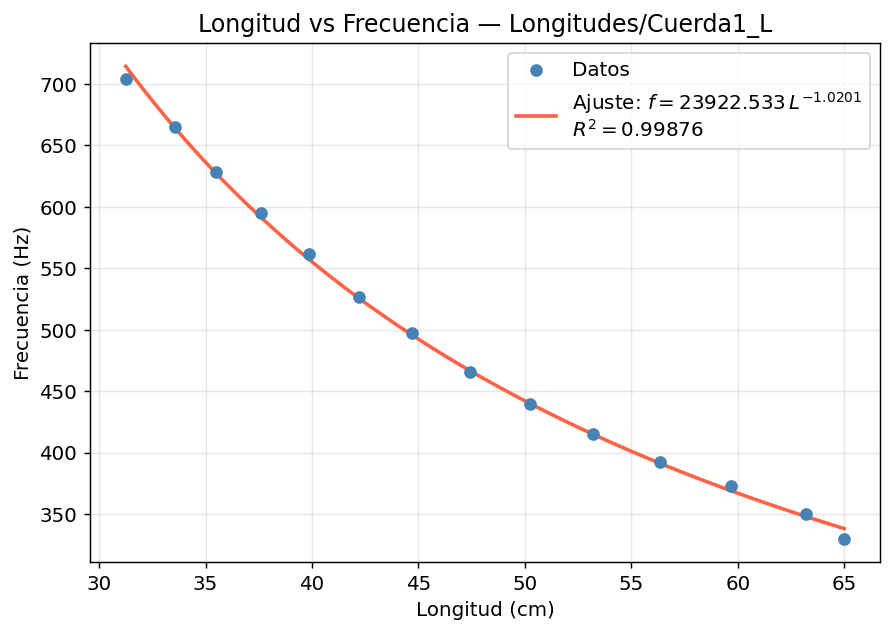

<Figure size 832x624 with 0 Axes>

In [85]:
# ============================================================
# Gráfica: Longitud vs Frecuencia (una cuerda)
# ============================================================
nombre_cuerda = os.path.splitext(ARCHIVO)[0]   

x = df["Longitud"].values.astype(float)
y = df["Frecuencia"].values.astype(float)

a, b, r2 = ajuste_potencial(x, y)

x_fit = np.linspace(x.min(), x.max(), 300)
y_fit = a * x_fit**b

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, color="steelblue", zorder=3, label="Datos")
ax.plot(x_fit, y_fit, color="tomato", linewidth=2,
        label=f"Ajuste: $f = {a:.3f}\\,L^{{{b:.4f}}}$\n$R^2 = {r2:.5f}$")

ax.set_xlabel("Longitud (cm)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title(f"Longitud vs Frecuencia — {nombre_cuerda}")
ax.legend()
plt.tight_layout()
plt.show()
plt.savefig(f"{nombre_cuerda}_LongitudVsFrecuencia.png", dpi=150)


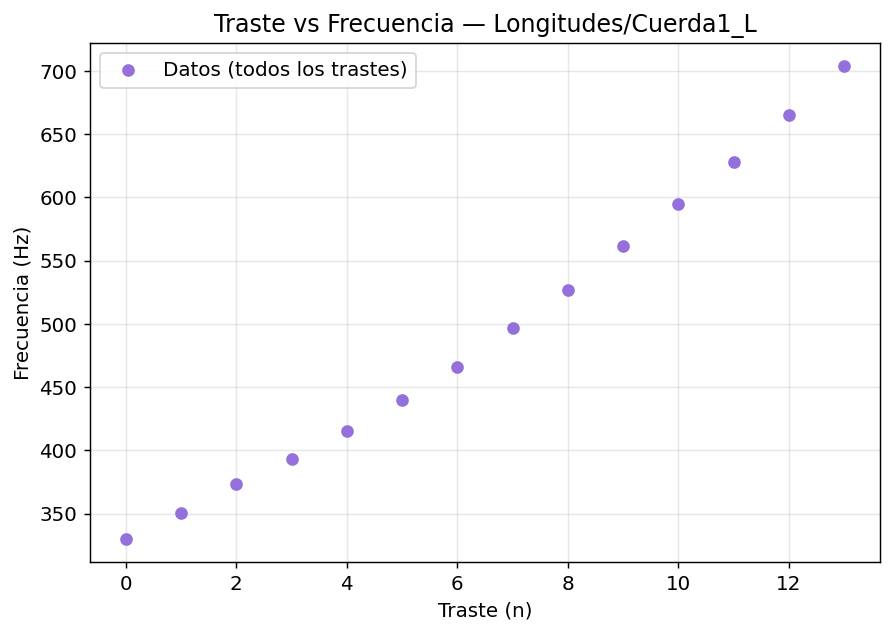

In [86]:
# ============================================================
# Gráfica: Traste vs Frecuencia (una cuerda)
# ============================================================

x_t = df["Traste"].values.astype(float)
y_t = df["Frecuencia"].values.astype(float)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_t, y_t,
           color="mediumpurple", zorder=3, label="Datos (todos los trastes)")

ax.set_xlabel("Traste (n)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title(f"Traste vs Frecuencia — {nombre_cuerda}")
ax.legend()
plt.tight_layout()
plt.show()

In [87]:
# ============================================================
#   Cargar TODAS las cuerdas        
# ============================================================
archivos = sorted(glob.glob("Longitudes/Cuerda*_L.csv"))
print(f"Archivos encontrados: {archivos}")

dfs = {}
for f in archivos:
    nombre = os.path.splitext(os.path.basename(f))[0]
    tmp = pd.read_csv(f)
    tmp.columns = ["Traste", "Inicio", "Final", "Longitud", "Frecuencia"]
    dfs[nombre] = tmp

print(f"\nTotal de cuerdas cargadas: {len(dfs)}")

Archivos encontrados: ['Longitudes/Cuerda1_L.csv', 'Longitudes/Cuerda2_L.csv', 'Longitudes/Cuerda3_L.csv', 'Longitudes/Cuerda4_L.csv', 'Longitudes/Cuerda5_L.csv', 'Longitudes/Cuerda6_L.csv']

Total de cuerdas cargadas: 6


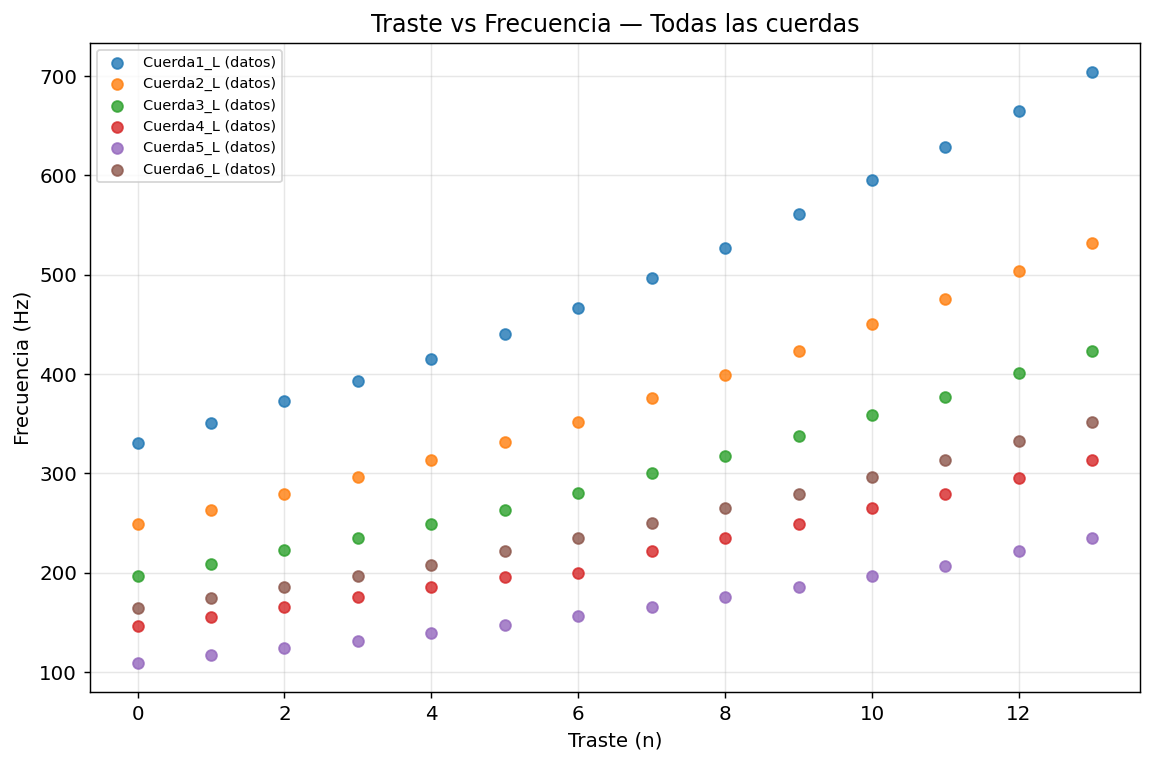

In [88]:
# ============================================================
# Gráfica combinada: Traste vs Frecuencia
# ============================================================

colores = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, data) in enumerate(dfs.items()):
    color = colores[i % len(colores)]

    x_t = data["Traste"].values.astype(float)
    y_t = data["Frecuencia"].values.astype(float)

    ax.scatter(x_t, y_t,
               color=color, zorder=3, alpha=0.8, label=f"{nombre} (datos)")

ax.set_xlabel("Traste (n)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title("Traste vs Frecuencia — Todas las cuerdas")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

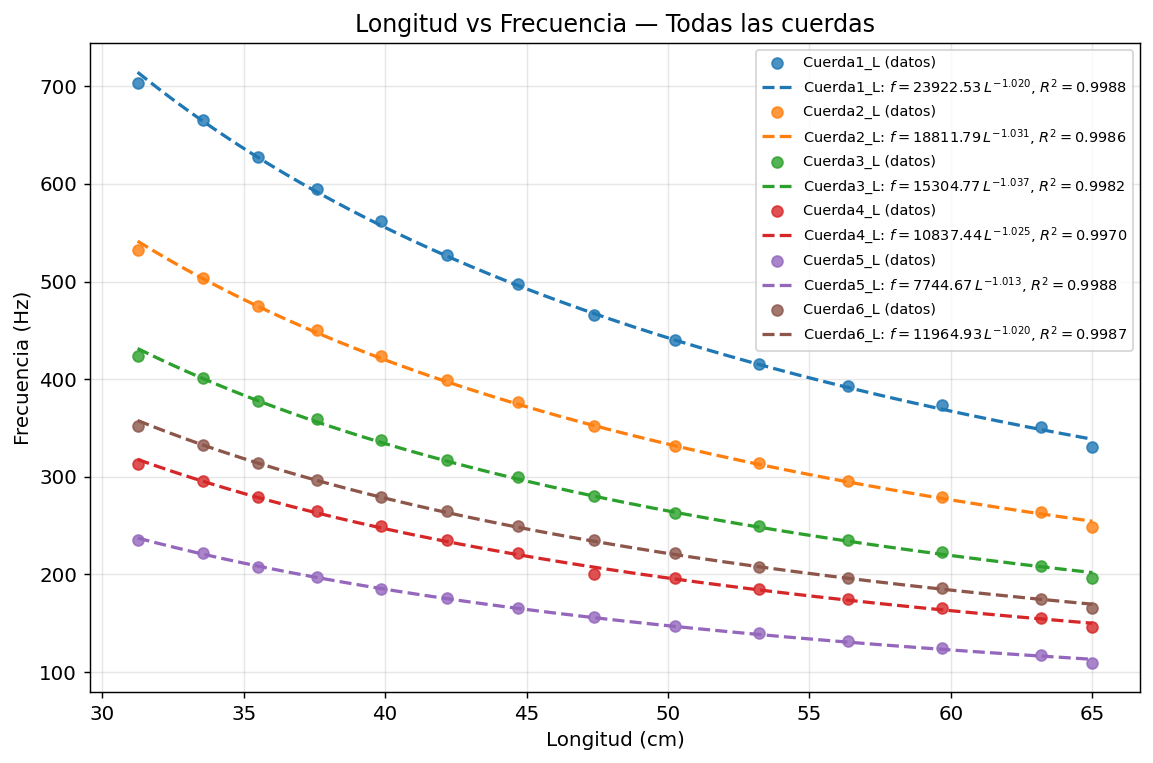

In [89]:
# ============================================================
# Gráfica combinada: Longitud vs Frecuencia 
# ============================================================
colores = plt.cm.tab10.colors   

fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, data) in enumerate(dfs.items()):
    color = colores[i % len(colores)]
    x = data["Longitud"].values.astype(float)
    y = data["Frecuencia"].values.astype(float)

    a, b, r2 = ajuste_potencial(x, y)
    x_fit = np.linspace(x.min(), x.max(), 300)

    ax.scatter(x, y, color=color, zorder=3, alpha=0.8, label=f"{nombre} (datos)")
    ax.plot(x_fit, a * x_fit**b, color=color, linewidth=1.8, linestyle="--",
            label=f"{nombre}: $f={a:.2f}\\,L^{{{b:.3f}}}$, $R^2={r2:.4f}$")

ax.set_xlabel("Longitud (cm)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title("Longitud vs Frecuencia — Todas las cuerdas")
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.savefig("Todas_LongitudVsFrecuencia.png", dpi=150)
plt.show()

<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_24836/806639821.py:38: SyntaxWarning: invalid escape sequence '\l'
  label=f"{nombre}: $\log(f) = {slope:.3f}\log(L) + {intercept:.2f}$ ($R^2={r2:.4f}$)")
/tmp/ipykernel_24836/806639821.py:38: SyntaxWarning: invalid escape sequence '\l'
  label=f"{nombre}: $\log(f) = {slope:.3f}\log(L) + {intercept:.2f}$ ($R^2={r2:.4f}$)")
/tmp/ipykernel_24836/806639821.py:45: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("$\log_{10}$ Longitud (cm)")
/tmp/ipykernel_24836/806639821.py:46: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("$\log_{10}$ Frecuencia (Hz

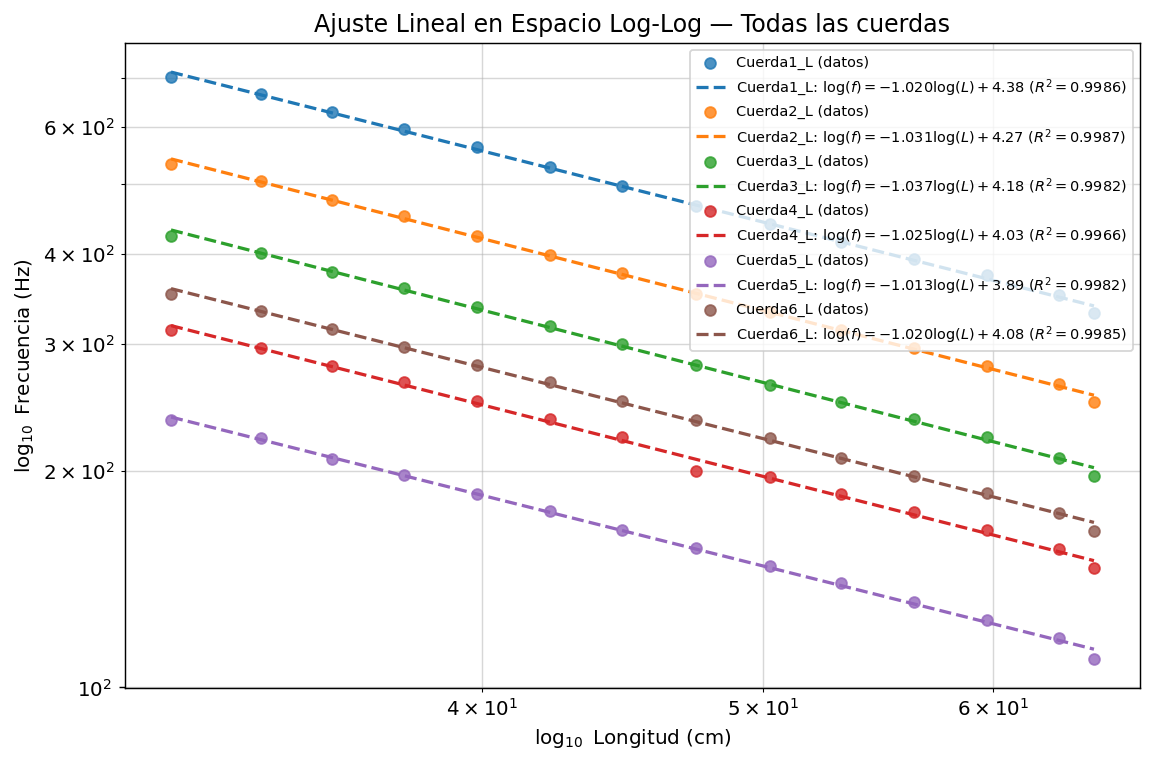

In [90]:
# =====================================================================
# Gráfica Log-Log: Longitud vs Frecuencia (Lineal)
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt

colores = plt.cm.tab10.colors 

fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, data) in enumerate(dfs.items()):
    color = colores[i % len(colores)]
    # Aseguramos que los datos sean float y filtramos valores <= 0 para evitar errores en log
    x = data["Longitud"].values.astype(float)
    y = data["Frecuencia"].values.astype(float)

    # Cálculo del ajuste lineal en espacio logarítmico
    # log(y) = b * log(x) + log(a)
    log_x = np.log10(x)
    log_y = np.log10(y)
    
    # Ajuste polinomial de grado 1 (recta)
    slope, intercept = np.polyfit(log_x, log_y, 1)
    
    # Coeficiente de correlación R²
    y_pred = slope * log_x + intercept
    r2 = 1 - (np.sum((log_y - y_pred)**2) / np.sum((log_y - np.mean(log_y))**2))

    # Graficamos los puntos en escala logarítmica
    ax.scatter(x, y, color=color, zorder=3, alpha=0.8, label=f"{nombre} (datos)")
    
    # Graficamos la recta de ajuste
    # Usamos x.min y x.max para que la línea cubra el rango de datos
    x_fit = np.geomspace(x.min(), x.max(), 100)
    y_fit = (10**intercept) * (x_fit**slope)
    
    ax.plot(x_fit, y_fit, color=color, linewidth=1.8, linestyle="--",
            label=f"{nombre}: $\log(f) = {slope:.3f}\log(L) + {intercept:.2f}$ ($R^2={r2:.4f}$)")

# Configuración de escalas logarítmicas
ax.set_xscale('log')
ax.set_yscale('log')

# Etiquetas y formato
ax.set_xlabel("$\log_{10}$ Longitud (cm)")
ax.set_ylabel("$\log_{10}$ Frecuencia (Hz)")
ax.set_title("Ajuste Lineal en Espacio Log-Log — Todas las cuerdas")
ax.grid(True, which="both", ls="-", alpha=0.5)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.savefig("LogLog_LongitudVsFrecuencia.png", dpi=150)
plt.show()

## Estudio Tensiones

Se utilizan las **6 cuerdas** de una guitarra. Para cada cuerda se gira la clavija a distintos ángulos acumulados y se cuelga **la misma masa** `m` en el centro de la cuerda, registrando el desplazamiento vertical `y` resultante.

| Ángulo de clavija | Descripción |
|---|---|
| 0° | Cuerda afinada (referencia) |
| +90° | Tensionada 90° respecto a la afinación |
| +180° | Tensionada 180° respecto a la afinación |
| −90° | Destensionada 90° respecto a la afinación |
| −180° | Destensionada 180° respecto a la afinación |
| ... | ... |


---
**Lógica física:** a mayor tensión en la cuerda → menor `y` al colgar el mismo peso → mayor `T` calculada.

In [91]:
# ============================================================
# Cargar datos de UNA cuerda específica
# ============================================================
ARCHIVO = "Tensiones/Cuerda1_T.csv" 

df = pd.read_csv(ARCHIVO)

# Eliminar espacios normales Y espacios no rompibles (\xa0)
df.columns = df.columns.str.replace(r'[\s\xa0]+', '', regex=True)

# Verificar nombres resultantes
print("Columnas detectadas:", df.columns.tolist())

df.columns = ["Angulo", "Tension", "Frecuencia"]

print(df)

Columnas detectadas: ['Ángulo', 'Tensión', 'Frecuencia']
    Angulo  Tension  Frecuencia
0     -900  48.6090  281.233568
1     -720  48.5114  285.750220
2     -630  48.7562  285.722919
3     -540  51.7205  285.156631
4     -450  54.2526  291.016800
5     -360  55.5500  297.857472
6     -270  56.5911  305.729121
7     -180  58.6400  318.019467
8      -90  61.3200  323.942989
9        0  71.7500  330.331191
10      90  74.5400  335.195531
11     180  78.3900  341.672623


In [92]:
# ============================================================
# Ajuste potencial 
# ============================================================
def ajuste_potencial(x, y):
    """
    Ajusta y = a * x^b usando regresión lineal en escala log-log.
    Solo funciona con x > 0 e y > 0.
    Retorna (a, b, R²).
    """
    log_x = np.log(x)
    log_y = np.log(y)
    coeffs = np.polyfit(log_x, log_y, 1)   # [b, log(a)]
    b = coeffs[0]
    a = np.exp(coeffs[1])

    y_pred = a * x**b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return a, b, r2

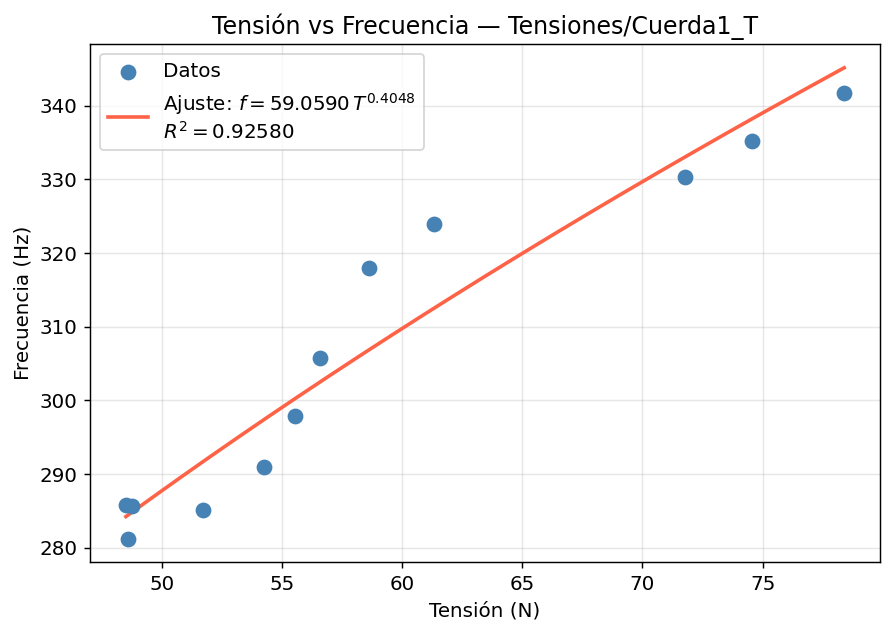

In [93]:
# ============================================================
# Gráfica: Tensión vs Frecuencia (UNA cuerda)
# ============================================================
nombre_cuerda = os.path.splitext(ARCHIVO)[0]  

x = df["Tension"].values.astype(float)
y = df["Frecuencia"].values.astype(float)

a, b, r2 = ajuste_potencial(x, y)

x_fit = np.linspace(x.min(), x.max(), 300)
y_fit = a * x_fit**b

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(x, y, color="steelblue", zorder=3, s=60, label="Datos")
ax.plot(x_fit, y_fit, color="tomato", linewidth=2,
        label=f"Ajuste: $f = {a:.4f}\\,T^{{{b:.4f}}}$\n$R^2 = {r2:.5f}$")

ax.set_xlabel("Tensión (N)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title(f"Tensión vs Frecuencia — {nombre_cuerda}")
ax.legend()
plt.tight_layout()
plt.savefig(f"{nombre_cuerda}_TensionVsFrecuencia.png", dpi=150)
plt.show()

In [94]:
# ============================================================
# Cargar TODAS las cuerdas
# ============================================================
archivos = sorted(glob.glob("Tensiones/Cuerda*_T.csv"))
print(f"Archivos encontrados: {archivos}")

dfs = {}
for f in archivos:
    nombre = os.path.splitext(os.path.basename(f))[0]
    
    # Leer sin asumir tipos, con engine flexible
    tmp = pd.read_csv(f, dtype=str, encoding_errors='replace')
    
    # Limpiar nombres de columna (espacios normales, \xa0, etc.)
    tmp.columns = tmp.columns.str.replace(r'[\s\xa0\u00a0]+', '', regex=True)
    
    # Renombrar por posición (más seguro que por nombre)
    tmp.columns = ["Angulo", "Tension", "Frecuencia"]
    
    # Convertir a numérico, cualquier basura se vuelve NaN y se elimina
    tmp["Tension"]    = pd.to_numeric(tmp["Tension"].str.replace(r'[\xa0\u00a0]', '', regex=True), errors='coerce')
    tmp["Frecuencia"] = pd.to_numeric(tmp["Frecuencia"].str.replace(r'[\xa0\u00a0]', '', regex=True), errors='coerce')
    tmp["Angulo"]     = pd.to_numeric(tmp["Angulo"].str.replace(r'[\xa0\u00a0]', '', regex=True), errors='coerce')
    
    # Eliminar filas donde Tension o Frecuencia sean NaN
    tmp.dropna(subset=["Tension", "Frecuencia"], inplace=True)
    tmp.reset_index(drop=True, inplace=True)
    
    print(f"\n{nombre} — {len(tmp)} filas válidas")
    print(tmp)
    
    dfs[nombre] = tmp

print(f"\nTotal de cuerdas cargadas: {len(dfs)}")

Archivos encontrados: ['Tensiones/Cuerda1_T.csv', 'Tensiones/Cuerda2_T.csv', 'Tensiones/Cuerda3_T.csv', 'Tensiones/Cuerda4_T.csv', 'Tensiones/Cuerda5_T.csv', 'Tensiones/Cuerda6_T.csv']

Cuerda1_T — 12 filas válidas
    Angulo  Tension  Frecuencia
0     -900  48.6090  281.233568
1     -720  48.5114  285.750220
2     -630  48.7562  285.722919
3     -540  51.7205  285.156631
4     -450  54.2526  291.016800
5     -360  55.5500  297.857472
6     -270  56.5911  305.729121
7     -180  58.6400  318.019467
8      -90  61.3200  323.942989
9        0  71.7500  330.331191
10      90  74.5400  335.195531
11     180  78.3900  341.672623

Cuerda2_T — 12 filas válidas
    Angulo  Tension  Frecuencia
0     -900  37.6844   213.95916
1     -720  38.2208   213.67584
2     -630  39.2769   212.10314
3     -540  42.3173   219.52484
4     -450  43.8455   225.36763
5     -360  45.3175   229.54467
6     -270  45.3175   229.54467
7     -180  45.7300   238.50932
8      -90  47.2300   244.31039
9        0  49.5500

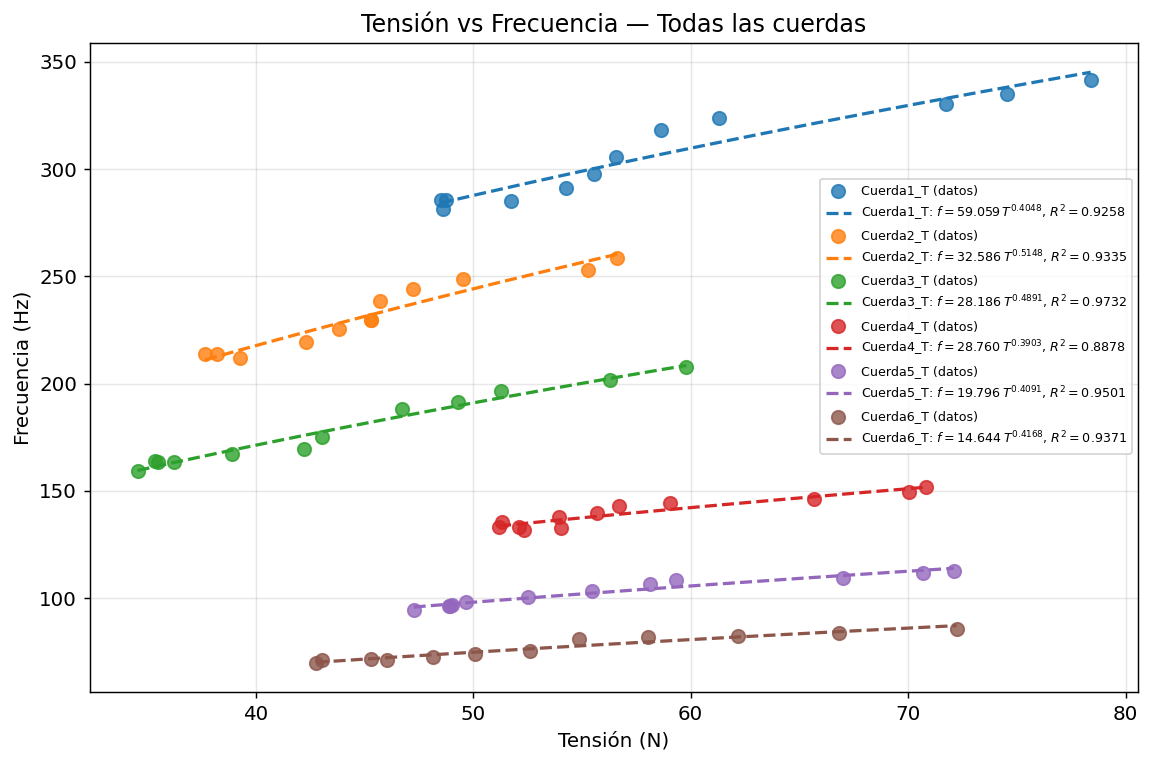

In [95]:
# ============================================================
# Gráfica combinada: Tensión vs Frecuencia (TODAS)
# ============================================================ 

fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, data) in enumerate(dfs.items()):
    color = colores[i % len(colores)]

    x = data["Tension"].values.astype(float)
    y = data["Frecuencia"].values.astype(float)

    a, b, r2 = ajuste_potencial(x, y)
    x_fit = np.linspace(x.min(), x.max(), 300)

    ax.scatter(x, y, color=color, zorder=3, alpha=0.8, s=55,
               label=f"{nombre} (datos)")
    ax.plot(x_fit, a * x_fit**b, color=color, linewidth=1.8, linestyle="--",
            label=f"{nombre}: $f={a:.3f}\\,T^{{{b:.4f}}}$, $R^2={r2:.4f}$")

ax.set_xlabel("Tensión (N)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title("Tensión vs Frecuencia — Todas las cuerdas")
ax.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.0, 0.8))
plt.tight_layout()
plt.savefig("Todas_TensionVsFrecuencia.png", dpi=150)
plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_24836/413573081.py:34: SyntaxWarning: invalid escape sequence '\l'
  label=f"{nombre}: $\log(f) = {slope:.3f}\log(T) + {intercept:.2f}$ ($R^2={r2:.4f}$)")
/tmp/ipykernel_24836/413573081.py:34: SyntaxWarning: invalid escape sequence '\l'
  label=f"{nombre}: $\log(f) = {slope:.3f}\log(T) + {intercept:.2f}$ ($R^2={r2:.4f}$)")


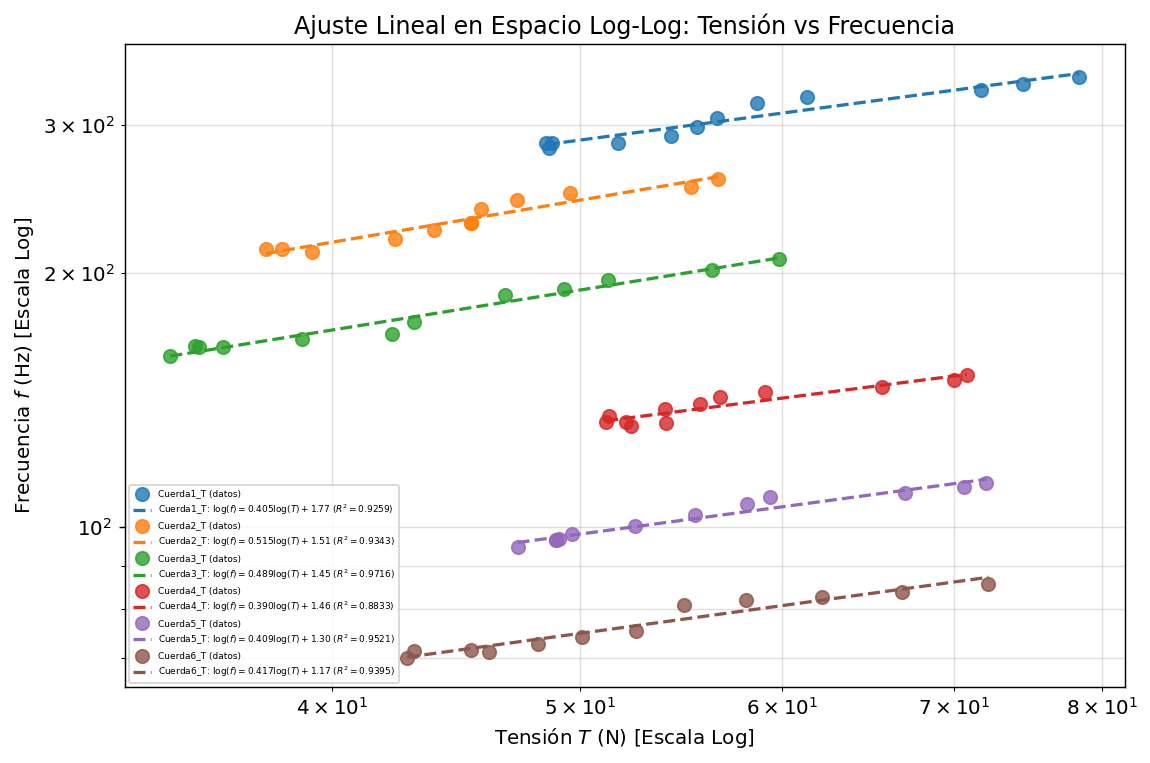

In [96]:
# =====================================================================
# Gráfica Log-Log: Tensión vs Frecuencia (Lineal)
# =====================================================================

fig, ax = plt.subplots(figsize=(9, 6))

for i, (nombre, data) in enumerate(dfs.items()):
    color = colores[i % len(colores)]
    
    # Extraemos datos asegurando que sean numéricos
    x = data["Tension"].values.astype(float)
    y = data["Frecuencia"].values.astype(float)

    # Transformación logarítmica para el ajuste lineal
    log_x = np.log10(x)
    log_y = np.log10(y)
    
    # Ajuste lineal: log(y) = slope * log(x) + intercept
    slope, intercept = np.polyfit(log_x, log_y, 1)
    
    # Cálculo del R² en el espacio logarítmico
    y_pred = slope * log_x + intercept
    r2 = 1 - (np.sum((log_y - y_pred)**2) / np.sum((log_y - np.mean(log_y))**2))

    # Puntos experimentales
    ax.scatter(x, y, color=color, zorder=3, alpha=0.8, s=55, label=f"{nombre} (datos)")
    
    # Generamos la curva de ajuste para escala logarítmica
    x_fit = np.geomspace(x.min(), x.max(), 100)
    y_fit = (10**intercept) * (x_fit**slope)
    
    # Graficamos la línea de ajuste
    ax.plot(x_fit, y_fit, color=color, linewidth=1.8, linestyle="--",
            label=f"{nombre}: $\log(f) = {slope:.3f}\log(T) + {intercept:.2f}$ ($R^2={r2:.4f}$)")

# Configuración de escalas logarítmicas en ambos ejes
ax.set_xscale('log')
ax.set_yscale('log')

# Etiquetas con notación matemática
ax.set_xlabel("Tensión $T$ (N) [Escala Log]")
ax.set_ylabel("Frecuencia $f$ (Hz) [Escala Log]")
ax.set_title("Ajuste Lineal en Espacio Log-Log: Tensión vs Frecuencia")

# Grilla técnica para escalas logarítmicas
ax.grid(True, which="both", ls="-", alpha=0.4)

# Ajuste de la leyenda para que no tape los datos
ax.legend(fontsize=5, loc='best')

plt.tight_layout()
plt.savefig("LogLog_TensionVsFrecuencia.png", dpi=150)
plt.show()

## Estudio Densidad

In [97]:
# ============================================================
# Cargar datos
# ============================================================
ARCHIVO = "Densidades/Densidades.csv"

df = pd.read_csv(ARCHIVO, index_col=0)
df.columns = df.columns.str.strip()
df.columns = ["Densidad", "Frecuencia"]
df.index   = df.index.str.strip()

df["Densidad"]   = pd.to_numeric(df["Densidad"],   errors="coerce")
df["Frecuencia"] = pd.to_numeric(df["Frecuencia"], errors="coerce")
df.dropna(inplace=True)

print(df)

          Densidad  Frecuencia
Cuerda 1  0.000399  330.331191
Cuerda 2  0.000477  248.704663
Cuerda 3  0.001030  196.415270
Cuerda 4  0.001620  146.440913
Cuerda 5  0.003500  109.600680
Cuerda 6  0.005780   81.915500


In [98]:
# ============================================================
#  Ajuste potencial
# ============================================================
def ajuste_potencial(x, y):
    """
    Ajusta y = a * x^b en escala log-log.
    Retorna (a, b, R²).
    """
    log_x  = np.log(x)
    log_y  = np.log(y)
    coeffs = np.polyfit(log_x, log_y, 1)   
    b = coeffs[0]
    a = np.exp(coeffs[1])

    y_pred = a * x**b
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2     = 1 - ss_res / ss_tot

    return a, b, r2

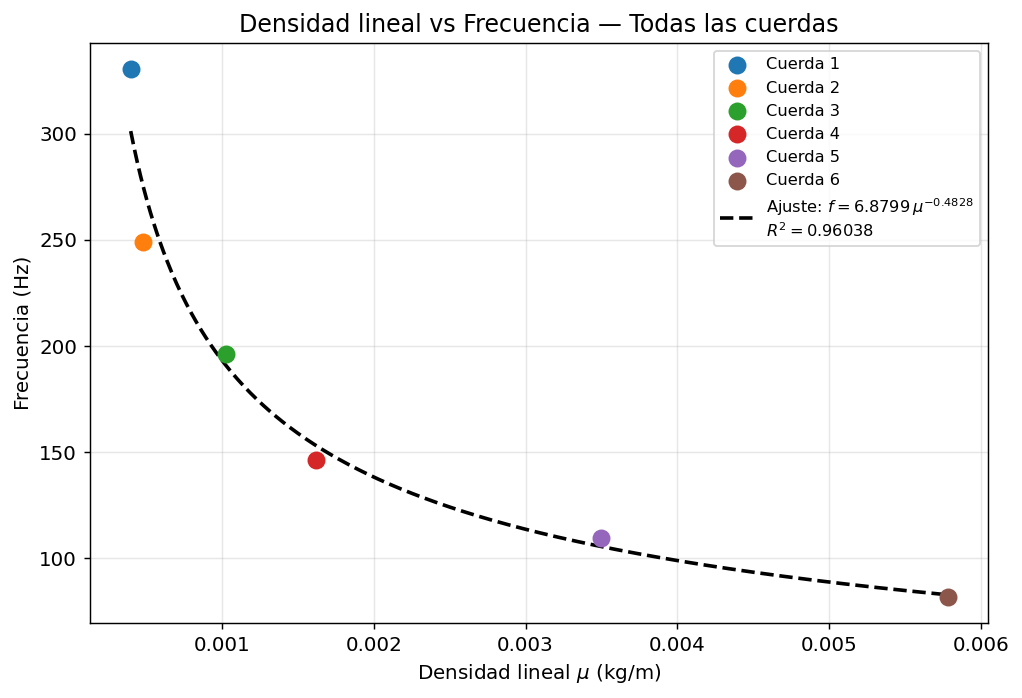

In [99]:
# ============================================================
# Gráfica: Densidad vs Frecuencia (todas las cuerdas)
# ============================================================
x = df["Densidad"].values
y = df["Frecuencia"].values

a, b, r2 = ajuste_potencial(x, y)

x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = a * x_fit**b

colores = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(8, 5.5))

# Scatter con etiqueta por cuerda
for i, (cuerda, row) in enumerate(df.iterrows()):
    ax.scatter(row["Densidad"], row["Frecuencia"],
               color=colores[i % len(colores)],
               s=80, zorder=4, label=cuerda)

# Línea de tendencia potencial
ax.plot(x_fit, y_fit, color="black", linewidth=2, linestyle="--",
        label=f"Ajuste: $f = {a:.4f}\\,\\mu^{{{b:.4f}}}$\n$R^2 = {r2:.5f}$")

ax.set_xlabel("Densidad lineal $\\mu$ (kg/m)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_title("Densidad lineal vs Frecuencia — Todas las cuerdas")
ax.legend(fontsize=9, loc="best")
plt.tight_layout()
plt.savefig("Densidad_vs_Frecuencia.png", dpi=150)
plt.show()

## Regresión Simbólica

In [100]:
df = pd.read_csv("Dataset.csv")  

# Verificación rápida
print(df.head())
print(df.dtypes)
print(f"Total de filas: {len(df)}")

   Frecuencia  Tension  Densidad  Longitud
0  330.331191    71.75  0.000399    0.6500
1  350.531976    71.75  0.000399    0.6320
2  373.100000    71.75  0.000399    0.5970
3  392.842768    71.75  0.000399    0.5635
4  415.391748    71.75  0.000399    0.5320
Frecuencia    float64
Tension       float64
Densidad      float64
Longitud      float64
dtype: object
Total de filas: 150


In [101]:
# Variables independientes
X = df[["Tension", "Densidad", "Longitud"]].values

# Variable objetivo
y = df["Frecuencia"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Rango de frecuencias:", y.min(), "–", y.max())

X shape: (150, 3)
y shape: (150,)
Rango de frecuencias: 69.93314567 – 703.7055


In [102]:
from pysr import PySRRegressor

model = PySRRegressor(
    niterations=1000, 
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sqrt"], 
    constraints={'/': (-1, 9), 'sqrt': 9}, 
    nested_constraints={"sqrt": {"sqrt": 0}}, 
    maxsize=12, 
    populations=30,
    variable_names=["T", "mu", "L"], 
    model_selection="best",
    verbosity=1,
    random_state=42,
)

model.fit(X, y)

/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.460e+06
Progress: 8405 / 30000 total iterations (28.017%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.662e+04  0.000e+00  y = 243.78
3           1.015e+04  2.458e-01  y = 128.45 / x₂
4           7.626e+03  2.851e-01  y = sqrt(x₀ / x₁)
5           7.626e+03  -0.000e+00  y = sqrt(x₀) / sqrt(x₁)
6           2.363e+03  1.171e+00  y = (4.0804 / sqrt(x₁)) / x₂
7           1.285e+03  6.093e-01  y = ((0.059106 / x₁) + x₀) / x₂
9           1.053e+03  9.917e-02  y = (((0.00084499 / x₁) * x₀) + 73.837) / x₂
10          1.027e+03  2.568e-02  y = ((0.05405 / x₁) + x₀) / (x₂ - sqrt(x₁))
11          8.933e+02  1.390e-01  y = ((((x₀ / x₁) * 0.0008527) + 101.36) / x₂) - x₀
────────────────────────────────────────────────────────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '-', ...]"
,unary_operators,['sqrt']
,expression_spec,None
,niterations,1000
,populations,30
,population_size,27
,max_evals,None
,maxsize,12
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20260502_191718_iI60Ji/hall_of_fame.csv


In [103]:
print(model)

PySRRegressor.equations_ = [
	   pick         score                                           equation  \
	0        0.000000e+00                                          243.78177   
	1        2.465971e-01                                     128.45232 / x2   
	2        2.857709e-01                                      sqrt(x0 / x1)   
	3        9.178582e-08                                sqrt(x0) / sqrt(x1)   
	4        1.171586e+00                         (4.080374 / sqrt(x1)) / x2   
	5  >>>>  6.095067e-01                      (x0 + (0.05910755 / x1)) / x2   
	6        9.924771e-02       (((x0 * 0.0008449898) / x1) + 73.83657) / x2   
	7        2.580532e-02         ((0.05404987 / x1) + x0) / (x2 - sqrt(x1))   
	8        1.390749e-01  ((((x0 * 0.0008526985) / x1) + 101.358055) / x...   
	9        2.891785e-02  (((sqrt(x0) * (0.006816221 / x1)) + 94.47007) ...   
	
	          loss  complexity  
	0  16619.68400           1  
	1  10149.18600           3  
	2   7626.45070           4  
	3

In [104]:
import sympy as sp
from IPython.display import display, Math


best_eq = model.sympy()


T, mu, L = sp.symbols('T mu L')

mapping = {
    'Tension': T,   'x0': T,
    'Densidad': mu, 'x1': mu, 'mu': mu,
    'Longitud': L,  'x2': L
}

final_eq = best_eq.subs({sp.Symbol(k): v for k, v in mapping.items() if sp.Symbol(k) in best_eq.free_symbols})

latex_str = sp.latex(final_eq)

print("Ecuación final corregida:")
display(Math(rf"f = {latex_str}")) 

Ecuación final corregida:


<IPython.core.display.Math object>

Se realizó una limpieza del Dataset, buscando eliminar los datos de tensiones que se ecnontraban alejados del ajuste potencial de 0.5

In [105]:
df = pd.read_csv("Dataset_Filtrado.csv")  

# Verificación rápida
print(df.head())
print(df.dtypes)
print(f"Total de filas: {len(df)}")

   Frecuencia  Tension  Densidad  Longitud
0  330.331191    71.75  0.000399    0.6500
1  350.531976    71.75  0.000399    0.6320
2  373.100000    71.75  0.000399    0.5970
3  392.842768    71.75  0.000399    0.5635
4  415.391748    71.75  0.000399    0.5320
Frecuencia    float64
Tension       float64
Densidad      float64
Longitud      float64
dtype: object
Total de filas: 106


In [106]:
# Variables independientes
X = df[["Tension", "Densidad", "Longitud"]].values

# Variable objetivo
y = df["Frecuencia"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Rango de frecuencias:", y.min(), "–", y.max())

X shape: (106, 3)
y shape: (106,)
Rango de frecuencias: 109.60068 – 703.7055


In [107]:
from pysr import PySRRegressor

model = PySRRegressor(
    niterations=1000, 
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sqrt"], 
    constraints={'/': (-1, 9), 'sqrt': 9}, 
    nested_constraints={"sqrt": {"sqrt": 0}}, 
    maxsize=12, 
    populations=30,
    variable_names=["T", "mu", "L"], 
    model_selection="best",
    verbosity=1,
    random_state=42,
)

model.fit(X, y)

/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.690e+06
Progress: 9250 / 30000 total iterations (30.833%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.561e+04  0.000e+00  y = 280.41
3           1.013e+04  2.152e-01  y = 134.21 / x₂
4           9.853e+03  2.719e-02  y = sqrt(x₀ / x₁)
5           9.099e+03  7.859e-02  y = (0.094978 / x₁) - -166.77
6           3.239e+03  1.032e+00  y = 4.1111 / (x₂ * sqrt(x₁))
7           1.503e+03  7.672e-01  y = ((0.049396 / x₁) + 77.248) / x₂
9           9.699e+02  2.191e-01  y = (((x₀ * 0.00078969) / x₁) + 80.948) / x₂
11          8.457e+02  6.843e-02  y = ((x₀ * ((0.00080341 / x₁) + -0.54297)) + 112.31) / x₂
───────────────────────────────────────────────────────────────────────────────────────────────────
══════════════════════════════════════════════

[ Info: Final population:
[ Info: Results saved to:


Progress: 27586 / 30000 total iterations (91.953%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.561e+04  0.000e+00  y = 280.41
3           1.013e+04  2.152e-01  y = 134.21 / x₂
4           9.853e+03  2.719e-02  y = sqrt(x₀ / x₁)
5           9.099e+03  7.859e-02  y = (0.094978 / x₁) - -166.77
6           3.239e+03  1.032e+00  y = (4.1111 / sqrt(x₁)) / x₂
7           1.503e+03  7.672e-01  y = ((0.049392 / x₁) + 77.255) / x₂
9           9.699e+02  2.191e-01  y = ((x₀ * (0.00078968 / x₁)) + 80.948) / x₂
11          8.457e+02  6.843e-02  y = ((x₀ * ((0.00080341 / x₁) + -0.54297)) + 112.31) / x₂
───────────────────────────────────────────────────────────────────────────────────────────────────
══════════════════════════════════════════════════════════════════════════════════════════

,model_selection,'best'
,binary_operators,"['+', '-', ...]"
,unary_operators,['sqrt']
,expression_spec,None
,niterations,1000
,populations,30
,population_size,27
,max_evals,None
,maxsize,12
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20260502_191736_ZbVl6k/hall_of_fame.csv


In [108]:
print(model)

PySRRegressor.equations_ = [
	   pick     score                                           equation  \
	0        0.000000                                          280.40714   
	1        0.215939                                     134.20776 / x2   
	2        0.028190                                      sqrt(x0 / x1)   
	3        0.079647                      (0.09497795 / x1) - -166.7708   
	4        1.033014                         (4.111116 / sqrt(x1)) / x2   
	5        0.767417               ((0.049392056 / x1) + 77.25472) / x2   
	6  >>>>  0.219159      ((x0 * (0.0007896768 / x1)) + 80.947556) / x2   
	7        0.068469  ((x0 * ((0.0008034075 / x1) + -0.54297495)) + ...   
	
	          loss  complexity  
	0  15609.05600           1  
	1  10134.78000           3  
	2   9853.06600           4  
	3   9098.73900           5  
	4   3238.53660           6  
	5   1503.36220           7  
	6    969.85016           9  
	7    845.73290          11  
]


In [109]:
import sympy as sp
from IPython.display import display, Math


best_eq = model.sympy()


T, mu, L = sp.symbols('T mu L')

mapping = {
    'Tension': T,   'x0': T,
    'Densidad': mu, 'x1': mu, 'mu': mu,
    'Longitud': L,  'x2': L
}

final_eq = best_eq.subs({sp.Symbol(k): v for k, v in mapping.items() if sp.Symbol(k) in best_eq.free_symbols})

latex_str = sp.latex(final_eq)

print("Ecuación final corregida:")
display(Math(rf"f = {latex_str}")) 

Ecuación final corregida:


<IPython.core.display.Math object>

Se realiza una linealización del modelo buscando que la regresion logré encontrar la realacion de amnera mas sencilla

$$\boxed{f = \frac{1}{2L}\sqrt{\frac{T}{\mu}}}$$

Buscando entonces:

$$\boxed{f^2 = 0.25 \cdot \frac{T}{\mu \cdot L^2}}$$


In [116]:
df_limpio = pd.read_csv('Dataset.csv')

# Variables independientes (Features)
X = df_limpio[['Tension', 'Densidad', 'Longitud']].values

# Variable objetivo (Target) elevada al cuadrado
y = (df_limpio['Frecuencia']**2).values

print("Preparación completada:")
print(f"- Registros cargados: {len(df_limpio)}")


Preparación completada:
- Registros cargados: 150


In [117]:
from pysr import PySRRegressor

# Configuración para buscar la estructura f^2 = (1/4) * T / (mu * L^2)
model = PySRRegressor(
    niterations=1000,            # Mayor profundidad de búsqueda
    binary_operators=["*", "/"],  # Operadores fundamentales para leyes de potencias
    unary_operators=[],           # No se requieren operadores unarios para el modelo f^2
    constraints={'/': (-1, 9)},   # Evita divisiones excesivamente complejas
    maxsize=12,                   # Restringe a una ecuación compacta y elegante
    variable_names=["T", "mu", "L"],
    model_selection="best",       # Elige el modelo con mejor equilibrio error/complejidad
    loss="loss(prediction, target) = (prediction - target)^2",
    random_state=42,
    verbosity=1
)

# Ajuste del modelo
model.fit(X, y)

/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.580e+06
Progress: 7330 / 31000 total iterations (23.645%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.177e+09  0.000e+00  y = 76059
3           3.723e+09  -0.000e+00  y = x₀ / x₁
5           1.857e+09  -0.000e+00  y = (37.111 / x₁) / x₂
7           7.028e+08  -0.000e+00  y = ((16.889 / x₂) / x₁) / x₂
9           3.482e+08  -0.000e+00  y = (((x₀ / x₁) * 0.27748) / x₂) / x₂
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.620e+06
Progress: 15227 / 31000 total iterations (49.119%)
═════════════════════════

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['*', '/']"
,unary_operators,[]
,expression_spec,None
,niterations,1000
,populations,31
,population_size,27
,max_evals,None
,maxsize,12
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20260502_192555_3NRWo6/hall_of_fame.csv


In [118]:
print(model)

PySRRegressor.equations_ = [
	   pick     score                              equation          loss  \
	0        0.000000                              76059.27  7.176517e+09   
	1        0.328102                               x0 / x1  3.723297e+09   
	2        0.347833                 (37.110928 / x1) / x2  1.856967e+09   
	3        0.485842           (16.88802 / x1) / (x2 * x2)  7.027604e+08   
	4  >>>>  0.351070  (((x0 / x1) * 0.27747637) / x2) / x2  3.482348e+08   
	
	   complexity  
	0           1  
	1           3  
	2           5  
	3           7  
	4           9  
]


In [119]:
import sympy as sp
from IPython.display import display, Math

best_model = model.get_best()
equation_sympy = best_model.sympy_format

T, mu, L = sp.symbols('T mu L')

mapping = {
    'Tension': T,   'x0': T,
    'Densidad': mu, 'x1': mu, 'mu': mu,
    'Longitud': L,  'x2': L
}


fixed_eq = equation_sympy.subs({sp.Symbol(k): v for k, v in mapping.items() if sp.Symbol(k) in equation_sympy.free_symbols})


simplified_eq = sp.simplify(fixed_eq)


latex_str = sp.latex(simplified_eq)


print("Resultado de la Regresión Simbólica para f²:")
display(Math(rf"f^2 = {latex_str}"))

Resultado de la Regresión Simbólica para f²:


<IPython.core.display.Math object>

Probamos el desempeño con la totalidad de los datos

In [113]:
df_limpio = pd.read_csv('Dataset_Filtrado.csv')

# Variables independientes (Features)
X = df_limpio[['Tension', 'Densidad', 'Longitud']].values

# Variable objetivo (Target) elevada al cuadrado
y = (df_limpio['Frecuencia']**2).values

print("Preparación completada:")
print(f"- Registros cargados: {len(df_limpio)}")


Preparación completada:
- Registros cargados: 106


In [114]:
# Configuración para buscar la estructura f^2 = (1/4) * T / (mu * L^2)
model = PySRRegressor(
    niterations=1000,            # Mayor profundidad de búsqueda
    binary_operators=["*", "/"],  # Operadores fundamentales para leyes de potencias
    unary_operators=[],           # No se requieren operadores unarios para el modelo f^2
    constraints={'/': (-1, 9)},   # Evita divisiones excesivamente complejas
    maxsize=12,                   # Restringe a una ecuación compacta y elegante
    variable_names=["T", "mu", "L"],
    model_selection="best",       # Elige el modelo con mejor equilibrio error/complejidad
    loss="loss(prediction, target) = (prediction - target)^2",
    random_state=42,
    verbosity=1
)

# Ajuste del modelo
model.fit(X, y)

/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
/home/sergio/Documentos/Entornos/MFC/lib/python3.12/site-packages/pysr/sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.790e+06
Progress: 8392 / 31000 total iterations (27.071%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           8.486e+09  0.000e+00  y = 94234
3           4.943e+09  -0.000e+00  y = x₀ / x₁
5           2.272e+09  -0.000e+00  y = (39.356 / x₁) / x₂
7           9.682e+08  -0.000e+00  y = ((16.979 / x₂) / x₁) / x₂
9           4.879e+08  -0.000e+00  y = x₀ / ((x₂ * (x₁ * 3.5964)) * x₂)
11          4.879e+08  -0.000e+00  y = x₀ / ((x₁ * x₂) / (2.3013 / (x₂ / 0.12083)))
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 1.8

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['*', '/']"
,unary_operators,[]
,expression_spec,None
,niterations,1000
,populations,31
,population_size,27
,max_evals,None
,maxsize,12
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20260502_191811_JIpkyq/hall_of_fame.csv


In [115]:
import sympy as sp
from IPython.display import display, Math

best_model = model.get_best()
equation_sympy = best_model.sympy_format

T, mu, L = sp.symbols('T mu L')

mapping = {
    'Tension': T,   'x0': T,
    'Densidad': mu, 'x1': mu, 'mu': mu,
    'Longitud': L,  'x2': L
}


fixed_eq = equation_sympy.subs({sp.Symbol(k): v for k, v in mapping.items() if sp.Symbol(k) in equation_sympy.free_symbols})


simplified_eq = sp.simplify(fixed_eq)


latex_str = sp.latex(simplified_eq)


print("Resultado de la Regresión Simbólica para f²:")
display(Math(rf"f^2 = {latex_str}"))

Resultado de la Regresión Simbólica para f²:


<IPython.core.display.Math object>